# 3. Metin Ön İşleme
Bu notebook, NLP modelleri için metin temizleme ve ekstra özellik çıkarımı adımlarını içerir.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

tqdm.pandas()

print('Veri yükleniyor...')
df = pd.read_csv('data/reviews_cleaned.csv')
print(f'Veri yüklendi, satır sayısı: {len(df):,}')

C:\Users\furkn\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\furkn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\furkn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\furkn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\furkn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\furkn\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Veri yükleniyor...


Veri yüklendi, satır sayısı: 89,268


## 3.1 Ek Feature Üretimi

In [2]:
print('Feature\'lar çıkarılıyor...')
df['text'] = df['text'].astype(str)

df['review_length'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count(r'\?')

def avg_word_len(text):
    words = text.split()
    if len(words) == 0: return 0
    return sum(len(w) for w in words) / len(words)

df['avg_word_length'] = df['text'].progress_apply(avg_word_len)

def upper_ratio(text):
    if len(text) == 0: return 0
    return sum(1 for c in text if c.isupper()) / len(text)

df['uppercase_ratio'] = df['text'].progress_apply(upper_ratio)

def get_sentiment(text):
    blob = TextBlob(text)
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

print('TextBlob sentiment hesaplanıyor...')
df[['sentiment_polarity','sentiment_subjectivity']] = df['text'].progress_apply(get_sentiment)

print('\nSınıflara göre feature ortalamaları:')
features = ['review_length','word_count','exclamation_count','question_count',
            'avg_word_length','uppercase_ratio','sentiment_polarity','sentiment_subjectivity']
print(df.groupby('label')[features].mean())

Feature'lar çıkarılıyor...


  0%|          | 0/89268 [00:00<?, ?it/s]

 15%|█▍        | 13059/89268 [00:00<00:00, 130589.81it/s]

 29%|██▉       | 26160/89268 [00:00<00:00, 130828.25it/s]

 44%|████▍     | 39243/89268 [00:00<00:00, 130409.87it/s]

...

 99%|█████████▉| 88647/89268 [00:41<00:00, 2217.76it/s]

100%|█████████▉| 88869/89268 [00:41<00:00, 2193.31it/s]

100%|█████████▉| 89089/89268 [00:42<00:00, 2137.25it/s]

100%|██████████| 89268/89268 [00:44<00:00, 2026.08it/s]


Sınıflara göre feature ortalamaları:
       review_length  word_count  exclamation_count  question_count  \
label                                                                 
0         465.265997   84.978156           0.610868        0.197910   
1         524.229970   96.171360           0.307871        0.135300   
2         424.502957   78.166823           0.839763        0.073565   

       avg_word_length  uppercase_ratio  sentiment_polarity  \
label                                                         
0             4.437216         0.034849            0.034347   
1             4.392146         0.028411            0.156642   
2             4.405749         0.032186            0.290586   

       sentiment_subjectivity  
label                          
0                    0.512801  
1                    0.519659  
2                    0.557767  


## 3.2 Metin Temizleme Fonksiyonu

In [3]:
stop_words = set(stopwords.words('english'))
# Olumsuzlama kelimelerini KORU: 'not good' temizlikte 'good'a dönüşmesin diye
# bu kelimeleri stopword listesinden çıkarıyoruz. Böylece TF-IDF bigram'ları
# ('not good', 'didn like' vb.) olumsuzluğu yakalayabiliyor.
negation_words = {'no','not','nor','never','none','nothing','neither','without','cannot',
                  'don','aren','couldn','didn','doesn','hadn','hasn','haven','isn',
                  'mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn','ain'}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(w) for w in tokens
               if w not in stop_words and len(w) >= 2]
    return ' '.join(cleaned)

## 3.3 Önce / Sonra Karşılaştırması

In [4]:
samples = df['text'].sample(5, random_state=42).tolist()
cleaned = [clean_text(t) for t in samples]

comp = pd.DataFrame({'Orijinal Metin': samples, 'Temizlenmiş Metin': cleaned})
pd.set_option('display.max_colwidth', None)
display(comp)

,Orijinal Metin,Temizlenmiş Metin
0,"This is the best price anywhere, unless you're buying it in 25- or 50-pound bags. I parted ways with refined sugar a long time ago, and since raw honey doesn't suit every recipe for which sweetness is called, Sucanat fills the gap beautifully. I've been testing ice cream recipes and it really does contribute a rich, caramel flavour to every blend. None of us has noticed the typical sugar highs and lows with this product, but perhaps that is due at least in part to always accompanying it with plenty of good fats.<br /><br />One caveat, though, and it is absolutely not a strike against this product: it won't make traditional caramel! Be forewarned. When heated and melted, it becomes molasses. I happen to like the bitter, smoky taste, but it didn't really suit the recipe. I'll just stick with its natural caramel qualities from now on.<br /><br />This small issue aside, it is a delicious, rich-tasting and high-quality product that will contribute a deep, full, warm taste and not just direct sweetness, to whatever you're cooking.",best price anywhere unless buying pound bag parted way refined sugar long time ago since raw honey doesn suit every recipe sweetness called sucanat fill gap beautifully testing ice cream recipe really contribute rich caramel flavour every blend none u noticed typical sugar high low product perhaps due least part always accompanying plenty good fat one caveat though absolutely not strike product won make traditional caramel forewarned heated melted becomes molasses happen like bitter smoky taste didn really suit recipe stick natural caramel quality small issue aside delicious rich tasting high quality product contribute deep full warm taste not direct sweetness whatever cooking
1,"I have some experience with expired Via coffee. Occasionally (not often) coffee inside turns into a solid but bendable flat stick inside the package so I would not say the date doesn't matter! In one case, because it was expired, Starbucks wouldn't replace it and said they'd seen it before. I love the coffee but beware that sometimes this does happen. Not sure why, possibly pinhole in packaging?<br /><br />update 10/16/2-12 video showing another ""chewing gum stick consistency"" Via found in not yet expired date. I'd open it to show but then I couldn't return.",experience expired via coffee occasionally not often coffee inside turn solid bendable flat stick inside package would not say date doesn matter one case expired starbucks wouldn replace said seen love coffee beware sometimes happen not sure possibly pinhole packaging update video showing another chewing gum stick consistency via found not yet expired date open show couldn return
2,"Although I am not a tea expert, but I do drink tea daily (not from tea bags).<br /><br />This tea is not the worst that I ever had, but for the price I can only rate it one star. The flavor is too mild or weak. From what I can tell, this should not even be classified as oolong tea.",although not tea expert drink tea daily not tea bag tea not worst ever price rate one star flavor mild weak tell not even classified oolong tea
3,"I purchased this product from WeSaveYou$ Storefront via Amazon on 7 Jun 2012 and when I received my order on 13 Jun 2012, the brew by date on each bag of coffee reads 1 May 2012. Aside from that, I love this coffee and always buy from Amazon. Avoid this seller!",purchased product wesaveyou storefront via amazon jun received order jun brew date bag coffee read may aside love coffee always buy amazon avoid seller
4,"Honestly... is it so hard to make a sugar free cookie that tastes good with all the sugar alternatives available in this day and age?<br /><br />I literally had to spit this out it was so awful. Just unreasonably bad.<br /><br />It was dry, hard, bitter, stale tasting, and nothing like peanut butter.<br /><br />I enjoy eating spinach more than these cookies.<br /><br />5 bucks I'll never get back.",honestly hard make sugar fr

## 3.4 Tüm Veriye Uygulama

In [5]:
print('Tüm metinler temizleniyor (bu adım uzun sürebilir)...')
df['cleaned_text'] = df['text'].progress_apply(clean_text)

initial_len = len(df)
df = df[df['cleaned_text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text'])
dropped = initial_len - len(df)
print(f'\nBoş kalan satır: {dropped}')
print(f'Kalan veri boyutu: {len(df):,}')

Tüm metinler temizleniyor (bu adım uzun sürebilir)...


  0%|          | 0/89268 [00:00<?, ?it/s]

  0%|          | 292/89268 [00:00<00:30, 2890.81it/s]

  1%|          | 597/89268 [00:00<00:29, 2983.52it/s]

  1%|          | 896/89268 [00:00<00:30, 2906.02it/s]

...

 99%|█████████▉| 88596/89268 [00:32<00:00, 2745.11it/s]

100%|█████████▉| 88871/89268 [00:32<00:00, 2701.88it/s]

100%|█████████▉| 89142/89268 [00:32<00:00, 2634.10it/s]

100%|██████████| 89268/89268 [00:32<00:00, 2719.94it/s]


Boş kalan satır: 1
Kalan veri boyutu: 89,267


## 3.5 Feature İstatistikleri

Feature istatistikleri:


review_length          word_count         exclamation_count         \
               mean      std       mean     std              mean    std   
label                                                                      
0           465.266  447.203     84.978  79.030             0.611  1.796   
1           524.230  501.358     96.171  88.751             0.308  0.964   
2           424.484  434.452     78.169  78.092             0.840  1.606   

      question_count        avg_word_length        uppercase_ratio         \
                mean    std            mean    std            mean    std   
label                                                                       
0              0.198  0.758           4.437  0.433           0.035  0.065   
1              0.135  0.575           4.392  0.404           0.028  0.049   
2              0.074  0.442           4.405  0.442           0.032  0.061   

      sentiment_polarity        sentiment_subjectivity         
                    mean    std                   mean    std  
label                                                          
0                  0.034  0.221                  0.513  0.169  
1                  0.157  0.176                  0.520  0.134  
2                  0.291  0.202                  0.558  0.144

C:\Users\furkn\AppData\Local\Temp\ipykernel_2096\4186494352.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y='sentiment_polarity', palette='Set2')


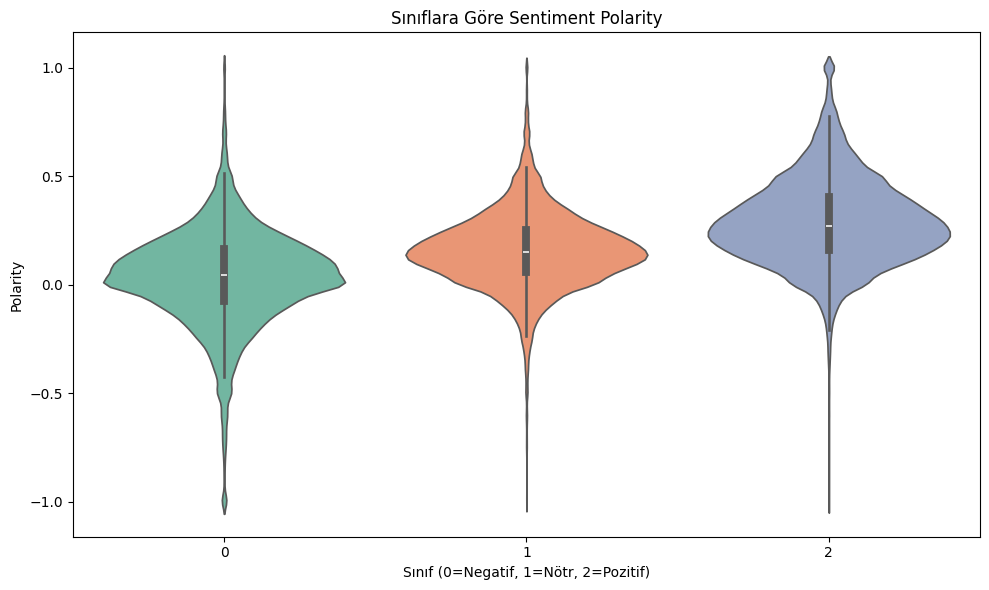

In [6]:
print('Feature istatistikleri:')
stats = df.groupby('label')[features].agg(['mean','std']).round(3)
display(stats)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='label', y='sentiment_polarity', palette='Set2')
plt.title('Sınıflara Göre Sentiment Polarity')
plt.xlabel('Sınıf (0=Negatif, 1=Nötr, 2=Pozitif)')
plt.ylabel('Polarity')
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/preprocessing_features.png')
plt.show()

## 3.6 Kaydet

In [7]:
output_csv = 'data/reviews_preprocessed.csv'
df.to_csv(output_csv, index=False)

os.makedirs('models', exist_ok=True)
joblib.dump(clean_text, 'models/preprocessor.pkl')

print(f'Kaydedildi: {output_csv}')
print('Kaydedildi: models/preprocessor.pkl')
display(df.head())

Kaydedildi: data/reviews_preprocessed.csv
Kaydedildi: models/preprocessor.pkl


,Id,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,summary,text,label,review_length,word_count,exclamation_count,question_count,avg_word_length,uppercase_ratio,sentiment_polarity,sentiment_subjectivity,cleaned_text
0,500162,B002ZJMRVY,A36WGHR8TO5DKT,0,0,1,1343174400,Seem like a ripoff to me,"These taste like inexpensive cracker and ""cheese"" packs. Actually the inexpensive packs taste and handle better than these do. These consist of two bland, sturdy (i.e., hard) rectangular crackers with a bland soft filling. So when you bite into them, the cracker parts snap into shards and the soft filling is squished out of the sides from the pressure of biting. They aren't even filling, not nearly as much as one of those cheap packets are. I really felt like this was one of the worst rip-off product concepts I'd fallen for in quite a while. It's all excessive packaging and marketing nonsense.",0,606,103,0,0,4.834951,0.013201,-0.082692,0.546795,taste like inexpensive cracker cheese pack actually inexpensive pack taste handle better consist two bland sturdy hard rectangular cracker bland soft filling bite cracker part snap shard soft filling squished side pressure biting aren even filling not nearly much one cheap packet really felt like one worst rip product concept fallen quite excessive packaging marketing nonsense
1,84967,B000H1195C,A2HN943685953U,2,4,3,1237248000,"Tasty, but has MSG...","For taste, enjoyment, and ease of preparation, I would have given this soup 5 stars. However, I was disappointed to learn that it contains MSG (Monosodium Glutamate). I really wish this did not have MSG, as I have to try and avoid the stuff.",1,243,44,0,0,4.500000,0.057613,-0.275000,0.475000,taste enjoyment ease preparation would given soup star however disappointed learn contains msg monosodium glutamate really wish not msg try avoid stuff
2,525330,B000H7K0Z6,A21OS50U19FDK6,2,2,5,1178496000,Relaxing moments,"Even if you are not a tea lover, you will love this tea. Great for the entire family(hot or cold).",2,98,20,0,0,3.950000,0.020408,0.175000,0.743750,even not tea lover love tea great entire family hot cold
3,556065,B001E5E0CE,A2OXGHLKJMK94N,0,5,3,1215129600,Coffee was fine; packacking was not...twice,"The coffee is fine. But, the first box I received was badly damaged, with four of the eight cans having beed crushed open. The reason: pooly packed with no bubble wrap or protection. I asked for repolacements, which were sent, but again, poorly packed and some cans were damaged. I talked to customer service, who just did not seem to get the fact that they need to pay attention to how they pack and ship. Otherwise fine.",1,425,77,0,0,4.493506,0.016471,-0.016667,0.457143,coffee fine first box received badly damaged four eight can beed crushed open reason pooly packed no bubble wrap protection asked repolacements sent poorly packed can damaged talked customer service not seem get fact need pay attention pack ship otherwise fine
4,373813,B004WTHCO2,A3K5BWPWIJXBA5,1,2,1,1299369600,Good only if you never tried simple alternatives - found it useless and returned,"The idea of this combine looks nice, but it is not very practical, and for sure quite expensive for the work it does. I owned it and decided to return when I tried steaming the quantity of veggies that I need using a simple steamer. Then I used a wonderful stick blender that I bought for just $30 dollars (Cusinart) and it worked great. Believe or not, it is less hassle this way. Less cleaning and drying. I could freeze extra amounts and use it later. Beaba will allow to steam and blend only a small set amount, and if your butter squash will happen to be larger, you have to do 2-3 batches, and so on. Plus the same time - 15 min, does not work well for all the veggies. In summary, making baby food using a pot, or steamer and then stick blender does not seem to be any more work than using Beaba; blending fresh fruits with stick blender is much easier than with Beaba (you have

## 3.7 Lemmatization vs Stemming
İki kök bulma yönteminin örnek tablosu ve küçük bir örneklemde model etkisi (F1-Macro).

In [8]:
# === EK ANALİZ: Lemmatization vs Stemming (örnek tablo) ===
import nltk, pandas as pd
from nltk.stem import PorterStemmer, WordNetLemmatizer

def wordnet_hazir():
    """WordNet korpusunu sağlar; yoksa (offline) indirmeyi dener."""
    try:
        nltk.data.find('corpora/wordnet'); return True
    except LookupError:
        try:
            nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True)
            nltk.data.find('corpora/wordnet'); return True
        except Exception:
            return False

stemmer = PorterStemmer(); lemmatizer = WordNetLemmatizer()
LEMMA_OK = wordnet_hazir()
ornek = ['running','better','studies','wolves','feet','flies','happily','caring','geese','tasted']
def lemma(w):
    return lemmatizer.lemmatize(w, pos='v') if LEMMA_OK else '(wordnet yok)'
tablo = pd.DataFrame({
    'Kelime': ornek,
    'Porter Stemmer': [stemmer.stem(w) for w in ornek],
    'WordNet Lemmatizer': [lemma(w) for w in ornek],
})
print('Stemming kelimeyi köke kabaca keser; Lemmatization sözlük tabanlı anlamlı köke indirger.')
if not LEMMA_OK:
    print('NOT: wordnet korpusu bulunamadı (internet gerekli). Lemmatization atlandı.')
display(tablo)

Stemming kelimeyi köke kabaca keser; Lemmatization sözlük tabanlı anlamlı köke indirger.
NOT: wordnet korpusu bulunamadı (internet gerekli). Lemmatization atlandı.


,Kelime,Porter Stemmer,WordNet Lemmatizer
0,running,run,(wordnet yok)
1,better,better,(wordnet yok)
2,studies,studi,(wordnet yok)
3,wolves,wolv,(wordnet yok)
4,feet,feet,(wordnet yok)
5,flies,fli,(wordnet yok)
6,happily,happili,(wordnet yok)
7,caring,care,(wordnet yok)
8,geese,gees,(wordnet yok)
9,tasted,tast,(wordnet yok)


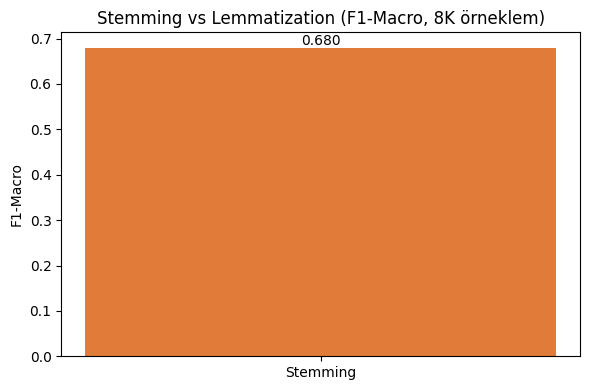

NOT: wordnet yok; yalnız Stemming gösterildi. İnternet olan ortamda iki yöntem de çalışır.


In [9]:
# === EK ANALİZ: Stemming vs Lemmatization model etkisi (8K örneklem) ===
import re, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
dfp = pd.read_csv('data/reviews_preprocessed.csv', usecols=['text', 'label']).dropna()
dfp = dfp.sample(min(8000, len(dfp)), random_state=42)
toks = dfp['text'].apply(lambda t: re.sub(r'[^a-z ]', ' ', str(t).lower()).split())
metinler = {'Stemming': toks.apply(lambda ws: ' '.join(stemmer.stem(w) for w in ws if len(w) > 2))}
if LEMMA_OK:
    metinler['Lemmatization'] = toks.apply(lambda ws: ' '.join(lemmatizer.lemmatize(w) for w in ws if len(w) > 2))
res = {}
for ad, metin in metinler.items():
    Xtr, Xte, ytr, yte = train_test_split(metin, dfp['label'], test_size=0.25,
                                          random_state=42, stratify=dfp['label'])
    v = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    clf = LogisticRegression(max_iter=500, class_weight='balanced').fit(v.fit_transform(Xtr), ytr)
    res[ad] = f1_score(yte, clf.predict(v.transform(Xte)), average='macro')
plt.figure(figsize=(6, 4))
plt.bar(res.keys(), res.values(), color=['#e07b39', '#3b8686'])
for i, (k, val) in enumerate(res.items()):
    plt.text(i, val, f'{val:.3f}', ha='center', va='bottom')
plt.title('Stemming vs Lemmatization (F1-Macro, 8K örneklem)'); plt.ylabel('F1-Macro')
plt.tight_layout(); plt.savefig('results/lemma_vs_stem.png'); plt.show()
if not LEMMA_OK:
    print('NOT: wordnet yok; yalnız Stemming gösterildi. İnternet olan ortamda iki yöntem de çalışır.')